In [13]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../nba.db")

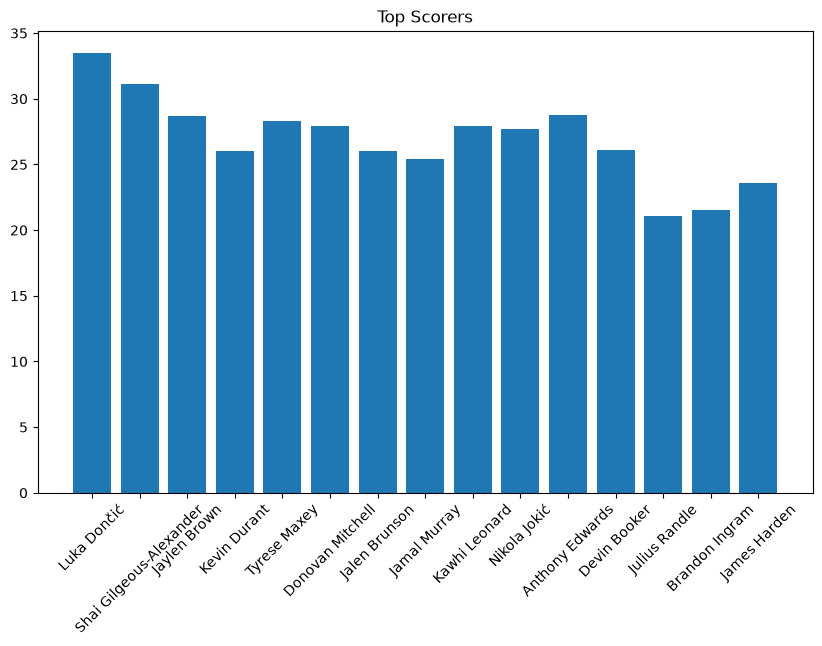

In [19]:
# What player scored the most points?

query = """
SELECT PLAYER_NAME, PTS AS PPG, PTS * GP AS TOTAL_POINTS
FROM season_stats
ORDER BY TOTAL_POINTS DESC
LIMIT 15;
"""

df = pd.read_sql_query(query, conn)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(df['PLAYER_NAME'], df['PPG'])
plt.xticks(rotation=45)
plt.title("Top Scorers")
plt.show()

In [15]:
# Which teams attempted the most threes?

query = """
SELECT TEAM_ABBREVIATION, SUM(FG3A * GP) AS TOTAL_THREES_ATTEMPTED
FROM season_stats
GROUP BY TEAM_ABBREVIATION
ORDER BY TOTAL_THREES_ATTEMPTED DESC
LIMIT 5;
"""

df = pd.read_sql_query(query, conn)
df

,TEAM_ABBREVIATION,TOTAL_THREES_ATTEMPTED
0,POR,3674.0
1,CHA,3591.3
2,CLE,3566.5
3,ATL,3548.8
4,GSW,3451.0


In [16]:
# What player averaged the most assists?

query = """
SELECT PLAYER_NAME, AST
FROM season_stats
ORDER BY AST DESC
LIMIT 10;
"""


df = pd.read_sql_query(query, conn)
df

,PLAYER_NAME,AST
0,Nikola Jokić,10.7
1,Cade Cunningham,9.9
2,Josh Giddey,9.1
3,Luka Dončić,8.3
4,Ja Morant,8.1
5,James Harden,8.0
6,Trae Young,8.0
7,Jalen Johnson,7.9
8,Andrew Nembhard,7.7
9,Kevin Porter Jr.,7.4


In [17]:
# Top rookies by points

query = """
SELECT r.PLAYER_NAME, s.PTS AS PPG, s.PTS * s.GP AS POINTS_TOTAL
FROM rookies r
LEFT JOIN season_stats s
    ON r.PERSON_ID = s.PLAYER_ID
WHERE r.SEASON = 2025
ORDER BY s.PTS DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)
df

,PLAYER_NAME,PPG,POINTS_TOTAL
0,Cooper Flagg,21.0,1470.0
1,Kon Knueppel,18.5,1498.5
2,VJ Edgecombe,16.0,1200.0
3,Jeremiah Fears,14.3,1172.6
4,Ace Bailey,13.8,993.6
5,Cedric Coward,13.6,843.2
6,Maxime Raynaud,12.5,925.0
7,Tre Johnson,12.2,732.0
8,Dylan Harper,11.8,814.2
9,Derik Queen,11.7,947.7


In [18]:
# What player had the highest field goal percentage (%)

query = """
SELECT PLAYER_NAME, FG_PCT, MIN
FROM season_stats
WHERE MIN >= 15
ORDER BY FG_PCT DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)
df

,PLAYER_NAME,FG_PCT,MIN
0,Jericho Sims,0.784,19.7
1,Jaxson Hayes,0.756,18.3
2,Ryan Kalkbrenner,0.753,21.4
3,Mitchell Robinson,0.723,19.6
4,Robert Williams III,0.708,17.1
5,Walker Kessler,0.703,30.8
6,Jakob Poeltl,0.700,25.0
7,Rudy Gobert,0.682,31.3
8,Goga Bitadze,0.676,15.2
9,Deandre Ayton,0.671,27.2
